In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

In [2]:
file_path='transposed_marathwada_dataset.csv'
target_col='level'

In [3]:
df = pd.read_csv(file_path)
df.shape

(2652, 12)

In [4]:
X = df.drop([target_col,'dem'], axis=1)
y = df[target_col]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
rf = RandomForestClassifier(
    n_estimators=100,         
    max_depth=10,          
    min_samples_split=2,    
    min_samples_leaf=2,      
    max_features='sqrt', 
    random_state=42
)

In [47]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, random_state=42)

In [48]:
y_pred = rf.predict(X_test)

In [49]:
print("Evaluation on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Evaluation on Test Set:
Accuracy: 0.935969868173258

Classification Report:
               precision    recall  f1-score   support

           1       0.94      1.00      0.97        50
           2       0.97      0.93      0.95       123
           3       0.93      0.90      0.91       119
           4       0.91      0.92      0.91       119
           5       0.94      0.97      0.96       120

    accuracy                           0.94       531
   macro avg       0.94      0.94      0.94       531
weighted avg       0.94      0.94      0.94       531



In [50]:

print("\nOverfitting Check:")
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))


Overfitting Check:
Train Accuracy: 0.9570957095709571
Test Accuracy: 0.935969868173258


In [51]:
cv_scores = cross_val_score(rf, X, y, cv=5)
print("\n🧪 Cross-Validation Accuracy:", cv_scores.mean())



🧪 Cross-Validation Accuracy: 0.913271506236009


📄 Classification Report:

              precision    recall  f1-score   support

           1       0.94      1.00      0.97        50
           2       0.97      0.93      0.95       123
           3       0.93      0.90      0.91       119
           4       0.91      0.92      0.91       119
           5       0.94      0.97      0.96       120

    accuracy                           0.94       531
   macro avg       0.94      0.94      0.94       531
weighted avg       0.94      0.94      0.94       531

🧾 Confusion Matrix:

[[ 50   0   0   0   0]
 [  3 114   6   0   0]
 [  0   4 107   8   0]
 [  0   0   2 109   8]
 [  0   0   0   3 117]]


/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


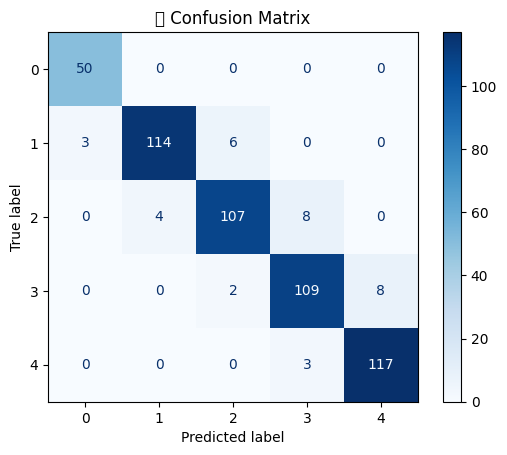

In [52]:
# Predict again (if not already done)
y_pred = rf.predict(X_test)

# 1. Classification Report (Precision, Recall, F1-score)
print("📄 Classification Report:\n")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix
print("🧾 Confusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 3. Visual Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("📊 Confusion Matrix")
plt.show()